# Chặng 2 — Cohort Analysis, Churn & Retention

**Nghịch lý cần verify từ BA team:**
> "Tệp KH của brand phân cực: mất tệp KH mua nhiều nhưng thường xuyên — giữ được tệp mua ít nhưng giá trị cao"

**Câu hỏi cụ thể:**
1. Cohort analysis: KH đăng ký năm X, đến năm X+1, X+2... còn mua không?
2. Churn Rate và Retention Rate theo từng cohort năm
3. CLV (Customer Lifetime Value) phân bố như thế nào?
4. Thời gian giữa lần mua 1 và lần mua 2 — trend theo năm
5. KH high-value vs low-value: ai đang churn nhiều hơn?

**File sử dụng:** `customers` · `orders` · `order_items`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)

INPUT_DIR = Path('input')

C_REV    = '#1D9E75'
C_CHURN  = '#E24B4A'
C_RET    = '#378ADD'
C_AOV    = '#EF9F27'
C_VOL    = '#888780'
C_HIGH   = '#7F77DD'
C_LOW    = '#D4537E'

print('✅ Setup OK')

✅ Setup OK


## 1. Load và chuẩn bị data

In [2]:
customers   = pd.read_csv(INPUT_DIR / 'customers.csv', parse_dates=['signup_date'])
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')

# Chỉ lấy delivered — đây là doanh thu thực sự
orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['Year']  = orders_d['order_date'].dt.year
orders_d['Month'] = orders_d['order_date'].dt.month

# Revenue per order
order_rev = order_items.groupby('order_id').apply(
    lambda g: (g['unit_price'] * g['quantity']).sum()
).reset_index()
order_rev.columns = ['order_id', 'order_revenue']

# Master table: mỗi row = 1 đơn hàng, kèm thông tin KH và revenue
txn = orders_d.merge(order_rev, on='order_id', how='left')
txn = txn.merge(
    customers[['customer_id','signup_date','gender','age_group','acquisition_channel']],
    on='customer_id', how='left'
)
txn['signup_year'] = txn['signup_date'].dt.year

print(f'Delivered orders: {len(txn):,}')
print(f'Unique customers: {txn["customer_id"].nunique():,}')
print(f'Date range: {txn["order_date"].min().date()} → {txn["order_date"].max().date()}')
print(f'Revenue range: {txn["order_revenue"].min():,.0f} → {txn["order_revenue"].max():,.0f}')

Delivered orders: 516,716
Unique customers: 85,115
Date range: 2012-07-04 → 2022-12-31
Revenue range: 535 → 331,570


## 2. Customer-level summary — CLV và purchase behavior

Tạo bảng tóm tắt **1 row = 1 khách hàng**, chứa toàn bộ lịch sử mua.

In [3]:
cust_summary = txn.groupby('customer_id').agg(
    n_orders        = ('order_id', 'count'),
    total_revenue   = ('order_revenue', 'sum'),
    avg_order_value = ('order_revenue', 'mean'),
    first_order     = ('order_date', 'min'),
    last_order      = ('order_date', 'max'),
    signup_date     = ('signup_date', 'first'),
    signup_year     = ('signup_year', 'first'),
    age_group       = ('age_group', 'first'),
    acquisition_channel = ('acquisition_channel', 'first'),
).reset_index()

cust_summary['customer_lifetime_days'] = (
    cust_summary['last_order'] - cust_summary['first_order']
).dt.days
cust_summary['first_order_year'] = cust_summary['first_order'].dt.year
cust_summary['last_order_year']  = cust_summary['last_order'].dt.year

# CLV = total_revenue (đây là realized CLV, không forecast)
cust_summary['CLV'] = cust_summary['total_revenue']

print('Customer summary stats:')
print(cust_summary[['n_orders','CLV','avg_order_value','customer_lifetime_days']].describe().round(0).to_string())
print(f'\nKH mua đúng 1 lần: {(cust_summary["n_orders"]==1).sum():,} ({(cust_summary["n_orders"]==1).mean()*100:.1f}%)')
print(f'KH mua >=2 lần   : {(cust_summary["n_orders"]>=2).sum():,} ({(cust_summary["n_orders"]>=2).mean()*100:.1f}%)')
print(f'KH mua >=5 lần   : {(cust_summary["n_orders"]>=5).sum():,} ({(cust_summary["n_orders"]>=5).mean()*100:.1f}%)')

Customer summary stats:
       n_orders          CLV  avg_order_value  customer_lifetime_days
count 85,115.00    85,115.00        85,115.00               85,115.00
mean       6.00   154,110.00        25,207.00                1,649.00
std        7.00   188,289.00        15,545.00                1,337.00
min        1.00       557.00           557.00                    0.00
25%        1.00    30,140.00        15,121.00                    0.00
50%        3.00    83,747.00        23,208.00                1,758.00
75%        8.00   207,404.00        31,708.00                2,923.00
max       93.00 2,964,142.00       202,023.00                3,829.00

KH mua đúng 1 lần: 22,843 (26.8%)
KH mua >=2 lần   : 62,272 (73.2%)
KH mua >=5 lần   : 35,366 (41.6%)


## 3. Cohort Analysis — Retention Matrix

**Cohort** = nhóm KH theo năm **mua lần đầu tiên** (first_order_year).  
**Retention** = % KH của cohort đó còn mua trong năm tiếp theo.

Đây là chart quan trọng nhất của chặng 2.

In [4]:
# Với mỗi KH, lấy danh sách các năm họ có mua
cust_years = txn.groupby('customer_id')['Year'].apply(set).reset_index()
cust_years.columns = ['customer_id', 'active_years']
cust_years = cust_years.merge(
    cust_summary[['customer_id','first_order_year']], on='customer_id'
)

# Cohort = first_order_year
# Period = năm offset từ cohort (0 = năm đầu, 1 = năm sau, ...)
all_years = sorted(txn['Year'].unique())
cohort_years = sorted(cust_years['first_order_year'].unique())

retention_matrix = {}
for cohort in cohort_years:
    cohort_custs = cust_years[cust_years['first_order_year'] == cohort]
    n_cohort = len(cohort_custs)
    row = {}
    for offset in range(len(all_years)):
        target_year = cohort + offset
        if target_year > max(all_years):
            break
        n_active = cohort_custs['active_years'].apply(lambda s: target_year in s).sum()
        row[offset] = round(n_active / n_cohort * 100, 1) if n_cohort > 0 else np.nan
    retention_matrix[cohort] = row

retention_df = pd.DataFrame(retention_matrix).T
retention_df.index.name = 'Cohort Year'
retention_df.columns = [f'Year +{i}' for i in retention_df.columns]

print('Retention Matrix (% KH cohort còn mua sau N năm):')
print(retention_df.round(1).to_string())
print('\n* Year +0 = năm đầu tiên (luôn = 100%)')

Retention Matrix (% KH cohort còn mua sau N năm):
             Year +0  Year +1  Year +2  Year +3  Year +4  Year +5  Year +6  Year +7  Year +8  Year +9  Year +10
Cohort Year                                                                                                    
2012          100.00    60.20    60.30    61.30    61.40    59.30    57.10    42.60    38.30    37.30     37.70
2013          100.00    48.10    48.40    48.30    46.80    44.90    32.40    28.80    27.60    28.10       NaN
2014          100.00    33.90    34.90    33.40    31.40    21.30    19.20    17.80    18.90      NaN       NaN
2015          100.00    27.50    26.70    24.50    16.10    14.10    13.20    13.80      NaN      NaN       NaN
2016          100.00    21.20    19.70    12.70    10.80    10.50    10.80      NaN      NaN      NaN       NaN
2017          100.00    16.10    11.20     9.30     9.30     8.20      NaN      NaN      NaN      NaN       NaN
2018          100.00     9.60     8.00     7.60     8.

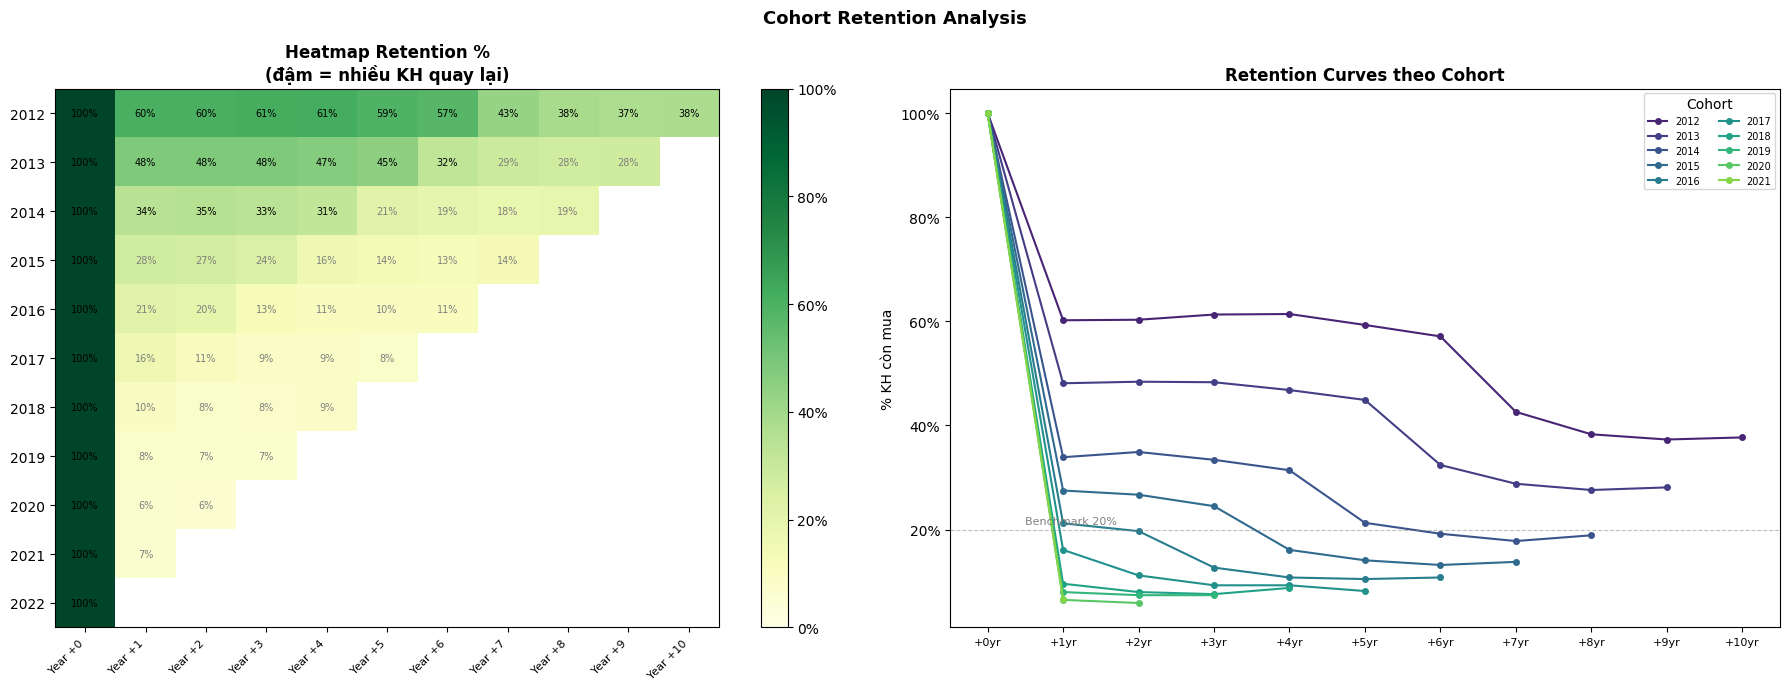

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Cohort Retention Analysis', fontsize=13, fontweight='bold')

# Heatmap retention
ax = axes[0]
data = retention_df.values.astype(float)
im = ax.imshow(data, cmap='YlGn', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, format='%.0f%%')
ax.set_xticks(range(len(retention_df.columns)))
ax.set_xticklabels(retention_df.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(retention_df.index)))
ax.set_yticklabels(retention_df.index)
ax.set_title('Heatmap Retention %\n(đậm = nhiều KH quay lại)', fontweight='bold')
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color='black' if val > 30 else 'gray')

# Line chart retention curves theo cohort
ax = axes[1]
colors_cohort = plt.cm.viridis(np.linspace(0.1, 0.9, len(cohort_years)))
for i, cohort in enumerate(cohort_years):
    row = retention_df.loc[cohort].dropna()
    if len(row) > 1:  # chỉ vẽ cohort có ít nhất 2 data points
        ax.plot(range(len(row)), row.values,
                label=str(cohort), color=colors_cohort[i],
                linewidth=1.5, marker='o', markersize=4)
ax.set_xticks(range(retention_df.shape[1]))
ax.set_xticklabels([f'+{i}yr' for i in range(retention_df.shape[1])], fontsize=8)
ax.set_title('Retention Curves theo Cohort', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.legend(title='Cohort', fontsize=7, ncol=2)
ax.set_ylabel('% KH còn mua')
ax.axhline(y=20, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.text(0.5, 21, 'Benchmark 20%', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## 4. Churn Rate theo năm

**Định nghĩa churn:** KH đã mua trong năm X nhưng không mua trong năm X+1.  
**Định nghĩa reactivation:** KH đã churn nhưng quay lại mua sau đó.

In [6]:
# Với mỗi năm, tính: active KH, churned, new, reactivated
yearly_metrics = []

for yr in sorted(all_years):
    if yr == min(all_years):
        continue  # cần năm trước để so sánh
    
    prev_yr = yr - 1
    
    active_prev = set(txn[txn['Year'] == prev_yr]['customer_id'])
    active_curr = set(txn[txn['Year'] == yr]['customer_id'])
    new_custs   = set(cust_summary[cust_summary['first_order_year'] == yr]['customer_id'])
    
    churned      = active_prev - active_curr
    retained     = active_prev & active_curr
    reactivated  = (active_curr - active_prev) - new_custs
    
    churn_rate = len(churned) / len(active_prev) * 100 if active_prev else 0
    ret_rate   = len(retained) / len(active_prev) * 100 if active_prev else 0
    
    yearly_metrics.append({
        'Year'          : yr,
        'n_active_prev' : len(active_prev),
        'n_active_curr' : len(active_curr),
        'n_new'         : len(new_custs),
        'n_retained'    : len(retained),
        'n_churned'     : len(churned),
        'n_reactivated' : len(reactivated),
        'churn_rate'    : round(churn_rate, 1),
        'retention_rate': round(ret_rate, 1),
    })

churn_df = pd.DataFrame(yearly_metrics)
print('Churn & Retention theo năm:')
print(churn_df[['Year','n_active_prev','n_retained','n_churned','n_new',
                'churn_rate','retention_rate']].to_string(index=False))

Churn & Retention theo năm:
 Year  n_active_prev  n_retained  n_churned  n_new  churn_rate  retention_rate
 2013          18759       11302       7457  23504       39.80           60.20
 2014          34806       19534      15272  13043       43.90           56.10
 2015          35673       20067      15606   8749       43.70           56.30
 2016          36050       20411      15639   6409       43.40           56.60
 2017          36242       19926      16316   4789       45.00           55.00
 2018          34957       18413      16544   3781       47.30           52.70
 2019          33307       13046      20261   1895       60.80           39.20
 2020          23401        8851      14550   1563       62.20           37.80
 2021          20839        7750      13089   1328       62.80           37.20
 2022          19945        7738      12207   1295       61.20           38.80


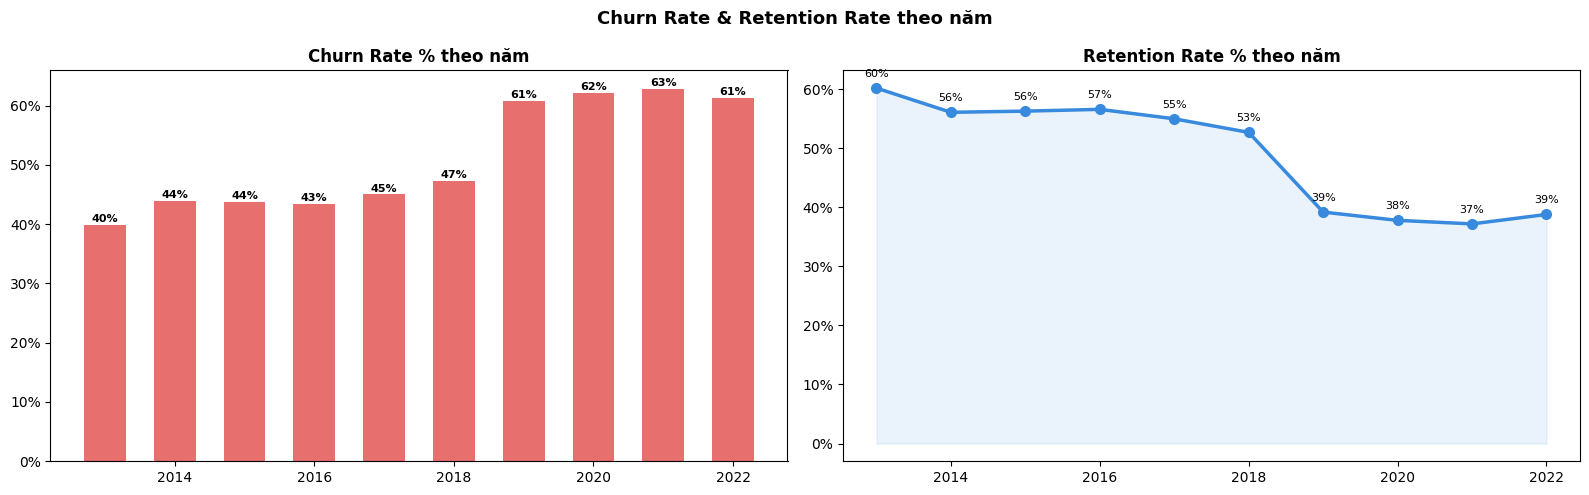


Churn Rate TB: 51.0%
Retention Rate TB: 49.0%
Năm churn cao nhất: 2021
Năm churn thấp nhất: 2013


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Churn Rate & Retention Rate theo năm', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(churn_df['Year'], churn_df['churn_rate'], color=C_CHURN, alpha=0.8, width=0.6)
ax.set_title('Churn Rate % theo năm', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
for x, y in zip(churn_df['Year'], churn_df['churn_rate']):
    ax.text(x, y + 0.5, f'{y:.0f}%', ha='center', fontsize=8, fontweight='bold')

ax = axes[1]
ax.plot(churn_df['Year'], churn_df['retention_rate'],
        color=C_RET, marker='o', linewidth=2.5, markersize=7)
ax.fill_between(churn_df['Year'], churn_df['retention_rate'], alpha=0.1, color=C_RET)
ax.set_title('Retention Rate % theo năm', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
for x, y in zip(churn_df['Year'], churn_df['retention_rate']):
    ax.annotate(f'{y:.0f}%', (x,y), textcoords='offset points',
                xytext=(0,8), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nChurn Rate TB: {churn_df["churn_rate"].mean():.1f}%')
print(f'Retention Rate TB: {churn_df["retention_rate"].mean():.1f}%')
print(f'Năm churn cao nhất: {churn_df.loc[churn_df["churn_rate"].idxmax(), "Year"]}')
print(f'Năm churn thấp nhất: {churn_df.loc[churn_df["churn_rate"].idxmin(), "Year"]}')

## 5. Waterfall: New vs Retained vs Churned theo năm

Chart này cho thấy cấu trúc tăng trưởng — Revenue đến từ KH mới hay KH cũ quay lại?

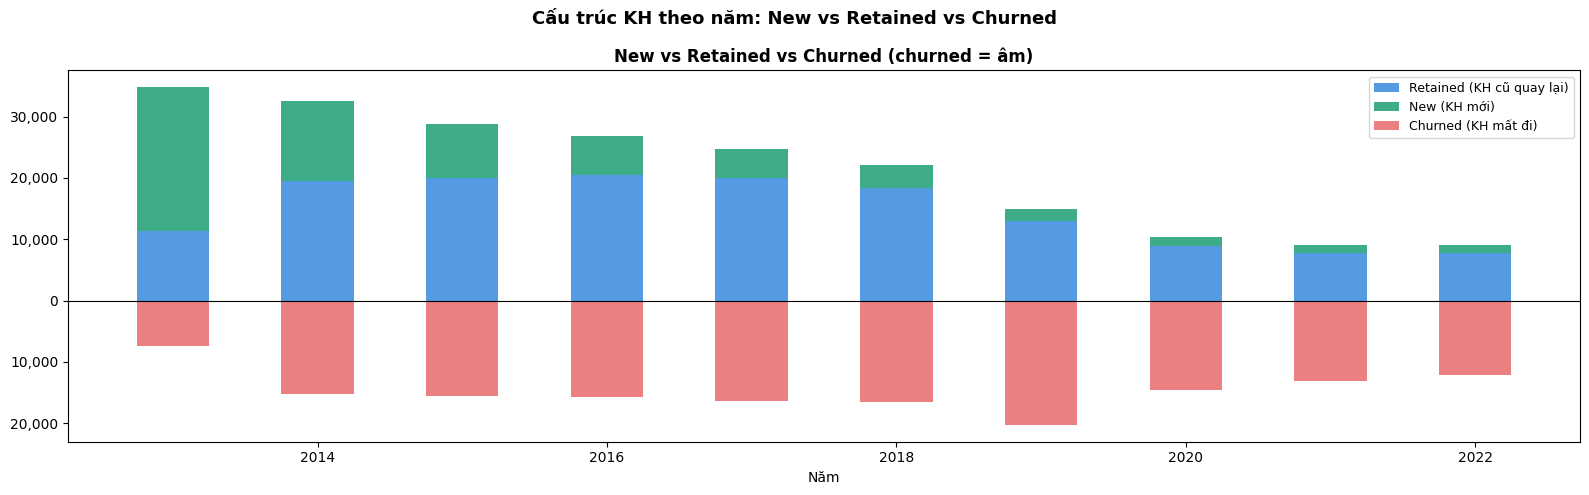


Revenue từ KH mới vs KH cũ (%):
 Year  rev_new_pct  rev_old_pct
 2013        58.90        41.10
 2014        26.40        73.60
 2015        15.90        84.10
 2016        11.20        88.80
 2017         8.80        91.20
 2018         7.40        92.60
 2019         5.80        94.20
 2020         5.80        94.20
 2021         5.10        94.90
 2022         4.80        95.20


In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Cấu trúc KH theo năm: New vs Retained vs Churned', fontsize=13, fontweight='bold')

width = 0.5
ax.bar(churn_df['Year'], churn_df['n_retained'],
       label='Retained (KH cũ quay lại)', color=C_RET, alpha=0.85, width=width)
ax.bar(churn_df['Year'], churn_df['n_new'],
       bottom=churn_df['n_retained'],
       label='New (KH mới)', color=C_REV, alpha=0.85, width=width)
ax.bar(churn_df['Year'], -churn_df['n_churned'],
       label='Churned (KH mất đi)', color=C_CHURN, alpha=0.7, width=width)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('New vs Retained vs Churned (churned = âm)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{abs(int(x)):,}'))
ax.legend(fontsize=9)
ax.set_xlabel('Năm')

plt.tight_layout()
plt.show()

# Tỷ lệ Revenue từ KH mới vs KH cũ
rev_by_type = []
for yr in sorted(all_years):
    if yr == min(all_years):
        continue
    new_ids = set(cust_summary[cust_summary['first_order_year'] == yr]['customer_id'])
    yr_txn  = txn[txn['Year'] == yr]
    rev_new = yr_txn[yr_txn['customer_id'].isin(new_ids)]['order_revenue'].sum()
    rev_old = yr_txn[~yr_txn['customer_id'].isin(new_ids)]['order_revenue'].sum()
    total   = rev_new + rev_old
    rev_by_type.append({
        'Year': yr,
        'rev_new_pct': rev_new/total*100 if total else 0,
        'rev_old_pct': rev_old/total*100 if total else 0,
    })

rev_type_df = pd.DataFrame(rev_by_type)
print('\nRevenue từ KH mới vs KH cũ (%):')
print(rev_type_df.round(1).to_string(index=False))

## 6. Verify hypothesis BA team: phân cực High-value vs Low-value

**Hypothesis:** Mất KH mua nhiều/thường xuyên, giữ KH mua ít nhưng giá trị cao.  
Phân KH thành 2 nhóm dựa trên CLV median, rồi xem churn rate của từng nhóm.

In [9]:
# Phân nhóm KH theo CLV
clv_median = cust_summary['CLV'].median()
clv_p75    = cust_summary['CLV'].quantile(0.75)

cust_summary['value_segment'] = pd.cut(
    cust_summary['CLV'],
    bins=[0, clv_median, clv_p75, float('inf')],
    labels=['Low-value', 'Mid-value', 'High-value']
)

print(f'CLV median: {clv_median:,.0f}')
print(f'CLV p75   : {clv_p75:,.0f}')
print()
print('Phân bổ KH theo value segment:')
print(cust_summary['value_segment'].value_counts().to_string())
print()

# Churn rate theo value segment
max_year = txn['Year'].max()
churn_window = 1  # KH không mua trong 1 năm gần nhất = churned

cust_summary['is_churned'] = cust_summary['last_order_year'] <= (max_year - churn_window)

churn_by_segment = cust_summary.groupby('value_segment').agg(
    n_customers  = ('customer_id', 'count'),
    n_churned    = ('is_churned', 'sum'),
    avg_clv      = ('CLV', 'mean'),
    avg_orders   = ('n_orders', 'mean'),
    avg_aov      = ('avg_order_value', 'mean'),
).reset_index()
churn_by_segment['churn_rate'] = churn_by_segment['n_churned'] / churn_by_segment['n_customers'] * 100

print('Churn Rate theo Value Segment:')
print(churn_by_segment[['value_segment','n_customers','churn_rate',
                         'avg_clv','avg_orders','avg_aov']].round(1).to_string(index=False))

CLV median: 83,747
CLV p75   : 207,404

Phân bổ KH theo value segment:
value_segment
Low-value     42558
High-value    21279
Mid-value     21278

Churn Rate theo Value Segment:
value_segment  n_customers  churn_rate    avg_clv  avg_orders   avg_aov
    Low-value        42558       91.40  34,173.30        1.90 20,250.80
    Mid-value        21278       74.20 135,593.20        5.30 31,311.60
   High-value        21279       47.10 412,500.10       15.20 29,016.00


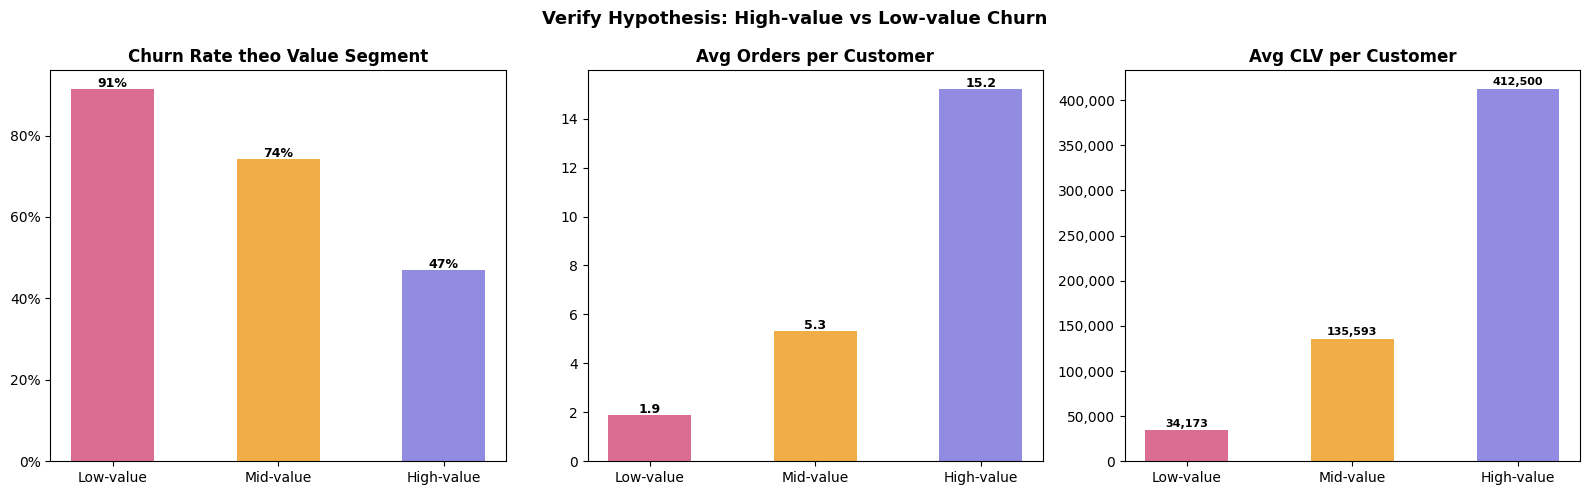


💡 Nếu High-value churn cao hơn Low-value → hypothesis BA team đúng


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Verify Hypothesis: High-value vs Low-value Churn', fontsize=13, fontweight='bold')

seg_colors = {'Low-value': C_LOW, 'Mid-value': C_AOV, 'High-value': C_HIGH}
segs  = churn_by_segment['value_segment'].astype(str)
colors_seg = [seg_colors.get(s, C_VOL) for s in segs]

ax = axes[0]
bars = ax.bar(segs, churn_by_segment['churn_rate'], color=colors_seg, alpha=0.85, width=0.5)
ax.set_title('Churn Rate theo Value Segment', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
for bar, val in zip(bars, churn_by_segment['churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

ax = axes[1]
bars = ax.bar(segs, churn_by_segment['avg_orders'], color=colors_seg, alpha=0.85, width=0.5)
ax.set_title('Avg Orders per Customer', fontweight='bold')
for bar, val in zip(bars, churn_by_segment['avg_orders']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

ax = axes[2]
bars = ax.bar(segs, churn_by_segment['avg_clv'], color=colors_seg, alpha=0.85, width=0.5)
ax.set_title('Avg CLV per Customer', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars, churn_by_segment['avg_clv']):
    ax.text(bar.get_x() + bar.get_width()/2, val + churn_by_segment['avg_clv'].max()*0.01,
            f'{val:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()
print('\n💡 Nếu High-value churn cao hơn Low-value → hypothesis BA team đúng')

## 7. Inter-purchase Time — Thời gian giữa lần mua 1 và lần mua 2

**BA team hỏi:** Thời gian giữa lần mua 1 và lần mua 2 thay đổi theo năm như thế nào?  
Nếu gap tăng dần → KH đang mua ít thường xuyên hơn → dấu hiệu suy giảm loyalty.

In [11]:
# Lấy KH mua >=2 lần, tính gap giữa lần 1 và lần 2
multi_buyers = cust_summary[cust_summary['n_orders'] >= 2]['customer_id']

# Với mỗi KH, sort orders theo ngày, lấy lần 1 và lần 2
orders_sorted = txn[txn['customer_id'].isin(multi_buyers)].sort_values(
    ['customer_id', 'order_date']
)

orders_sorted['order_rank'] = orders_sorted.groupby('customer_id').cumcount() + 1
order_1 = orders_sorted[orders_sorted['order_rank'] == 1][['customer_id','order_date']].rename(columns={'order_date':'date_1'})
order_2 = orders_sorted[orders_sorted['order_rank'] == 2][['customer_id','order_date']].rename(columns={'order_date':'date_2'})

gap_df = order_1.merge(order_2, on='customer_id')
gap_df['gap_days'] = (gap_df['date_2'] - gap_df['date_1']).dt.days
gap_df['cohort_year'] = gap_df['date_1'].dt.year

print(f'KH mua >=2 lần: {len(gap_df):,}')
print(f'\nGap 1→2 tổng thể (ngày):')
print(f'  Mean  : {gap_df["gap_days"].mean():.0f} ngày')
print(f'  Median: {gap_df["gap_days"].median():.0f} ngày')
print(f'  p25   : {gap_df["gap_days"].quantile(0.25):.0f} ngày')
print(f'  p75   : {gap_df["gap_days"].quantile(0.75):.0f} ngày')

print('\nGap 1→2 trung bình theo năm mua đầu tiên:')
gap_by_year = gap_df.groupby('cohort_year')['gap_days'].agg(['mean','median','count']).round(0)
print(gap_by_year.to_string())

KH mua >=2 lần: 62,272

Gap 1→2 tổng thể (ngày):
  Mean  : 549 ngày
  Median: 326 ngày
  p25   : 112 ngày
  p75   : 756 ngày

Gap 1→2 trung bình theo năm mua đầu tiên:
              mean  median  count
cohort_year                      
2012        434.00  238.00  17599
2013        541.00  314.00  20874
2014        653.00  422.00  10136
2015        668.00  453.00   5936
2016        647.00  454.00   3557
2017        607.00  426.00   2036
2018        610.00  488.00   1221
2019        516.00  456.00    447
2020        361.00  321.00    251
2021        235.00  211.00    150
2022         82.00   64.00     65


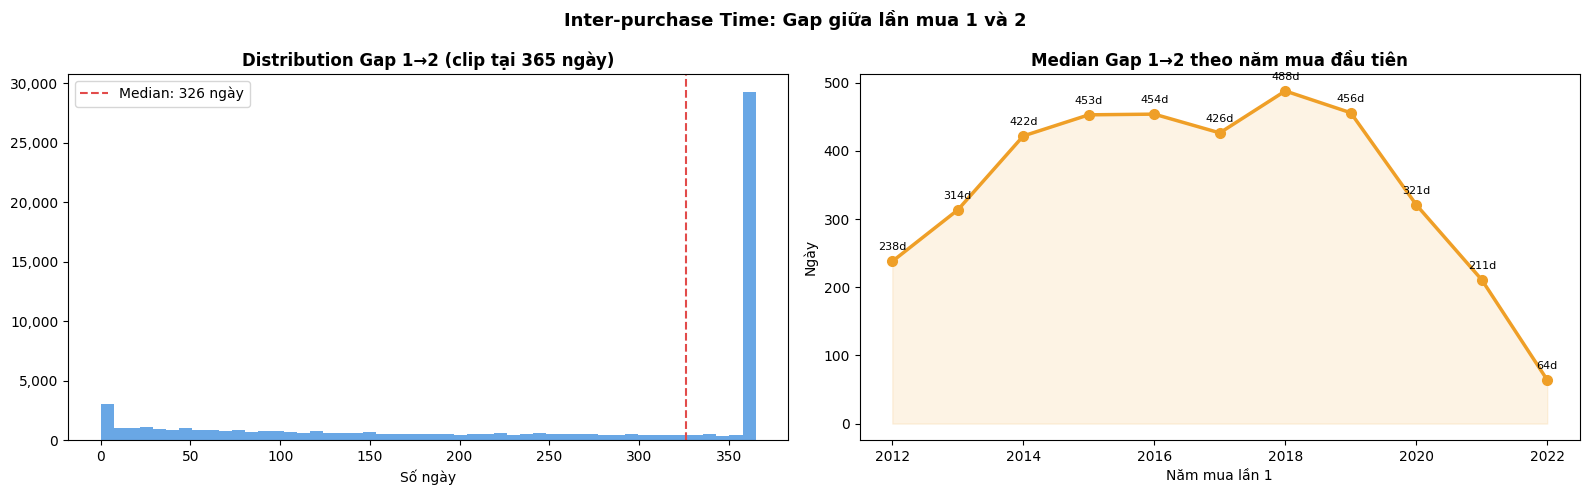


💡 Gap tăng theo năm → KH gần đây mua ít thường xuyên hơn KH cũ


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Inter-purchase Time: Gap giữa lần mua 1 và 2', fontsize=13, fontweight='bold')

# Distribution của gap
ax = axes[0]
gap_clip = gap_df['gap_days'].clip(upper=365)  # clip tại 1 năm cho dễ nhìn
ax.hist(gap_clip, bins=50, color=C_RET, alpha=0.75, edgecolor='none')
ax.axvline(gap_df['gap_days'].median(), color=C_CHURN, linestyle='--',
           linewidth=1.5, label=f'Median: {gap_df["gap_days"].median():.0f} ngày')
ax.set_title('Distribution Gap 1→2 (clip tại 365 ngày)', fontweight='bold')
ax.set_xlabel('Số ngày')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Trend gap theo năm
ax = axes[1]
gap_trend = gap_df.groupby('cohort_year')['gap_days'].median().reset_index()
ax.plot(gap_trend['cohort_year'], gap_trend['gap_days'],
        color=C_AOV, marker='o', linewidth=2.5, markersize=7)
ax.fill_between(gap_trend['cohort_year'], gap_trend['gap_days'], alpha=0.12, color=C_AOV)
ax.set_title('Median Gap 1→2 theo năm mua đầu tiên', fontweight='bold')
ax.set_xlabel('Năm mua lần 1')
ax.set_ylabel('Ngày')
for x, y in zip(gap_trend['cohort_year'], gap_trend['gap_days']):
    ax.annotate(f'{y:.0f}d', (x,y), textcoords='offset points',
                xytext=(0,8), ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print('\n💡 Gap tăng theo năm → KH gần đây mua ít thường xuyên hơn KH cũ')

## 8. CLV Distribution và top KH

Hiểu phân phối CLV: brand đang phụ thuộc vào bao nhiêu % KH cho X% doanh thu?

Top 10% KH đóng góp 39.1% Revenue
Top 20% KH đóng góp 59.5% Revenue
Top 30% KH đóng góp 73.1% Revenue
Top 50% KH đóng góp 88.9% Revenue


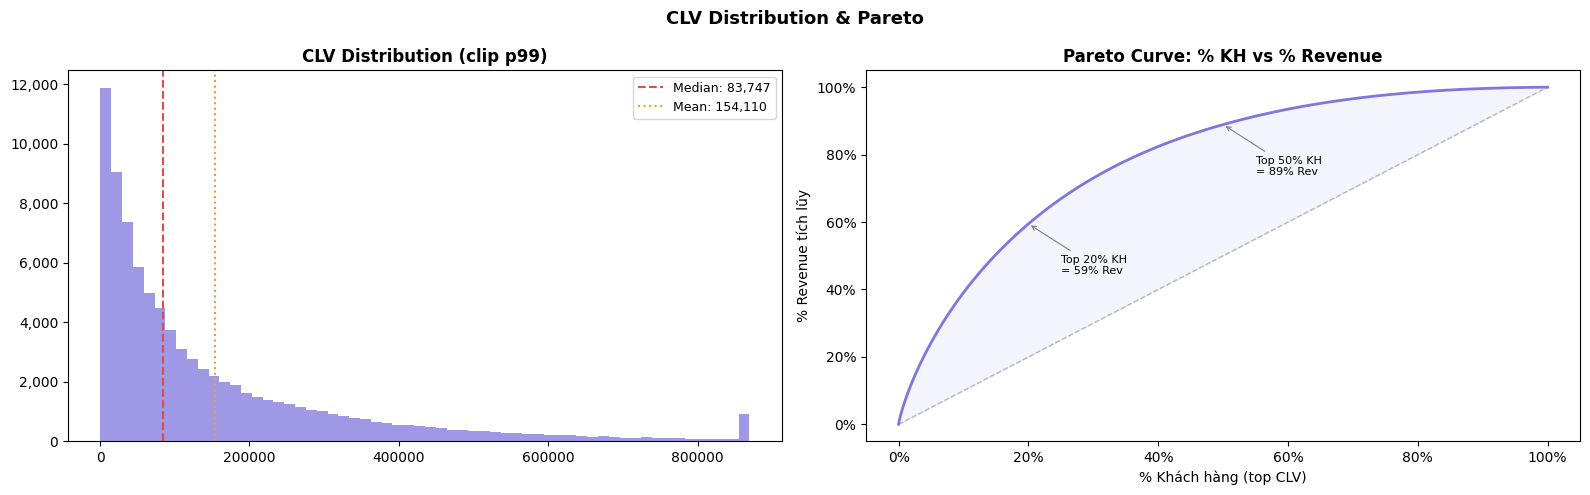

In [13]:
# Pareto: top X% KH đóng góp bao nhiêu % Revenue
cust_sorted = cust_summary.sort_values('CLV', ascending=False).reset_index(drop=True)
cust_sorted['cumulative_rev_pct'] = cust_sorted['CLV'].cumsum() / cust_sorted['CLV'].sum() * 100
cust_sorted['cumulative_cust_pct'] = (cust_sorted.index + 1) / len(cust_sorted) * 100

# Check Pareto thresholds
for threshold in [10, 20, 30, 50]:
    rev_pct = cust_sorted[cust_sorted['cumulative_cust_pct'] <= threshold]['cumulative_rev_pct'].max()
    print(f'Top {threshold}% KH đóng góp {rev_pct:.1f}% Revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('CLV Distribution & Pareto', fontsize=13, fontweight='bold')

# CLV histogram
ax = axes[0]
clv_clip = cust_summary['CLV'].clip(upper=cust_summary['CLV'].quantile(0.99))
ax.hist(clv_clip, bins=60, color=C_HIGH, alpha=0.75, edgecolor='none')
ax.axvline(cust_summary['CLV'].median(), color=C_CHURN, linestyle='--',
           linewidth=1.5, label=f'Median: {cust_summary["CLV"].median():,.0f}')
ax.axvline(cust_summary['CLV'].mean(), color=C_AOV, linestyle=':',
           linewidth=1.5, label=f'Mean: {cust_summary["CLV"].mean():,.0f}')
ax.set_title('CLV Distribution (clip p99)', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Pareto curve
ax = axes[1]
ax.plot(cust_sorted['cumulative_cust_pct'], cust_sorted['cumulative_rev_pct'],
        color=C_HIGH, linewidth=2)
ax.plot([0,100],[0,100], color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.fill_between(cust_sorted['cumulative_cust_pct'],
                cust_sorted['cumulative_rev_pct'],
                cust_sorted['cumulative_cust_pct'],
                alpha=0.08, color=C_HIGH)
for pct in [20, 50]:
    rev = cust_sorted[cust_sorted['cumulative_cust_pct'] <= pct]['cumulative_rev_pct'].max()
    ax.annotate(f'Top {pct}% KH\n= {rev:.0f}% Rev',
                xy=(pct, rev), xytext=(pct+5, rev-15),
                fontsize=8, arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax.set_title('Pareto Curve: % KH vs % Revenue', fontweight='bold')
ax.set_xlabel('% Khách hàng (top CLV)')
ax.set_ylabel('% Revenue tích lũy')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

## 9. Tổng kết Chặng 2

In [14]:
print('='*65)
print('📋  CHẶNG 2 — TỔNG KẾT PHÁT HIỆN')
print('='*65)

one_time = (cust_summary['n_orders']==1).mean()*100
is_churned_pct = cust_summary['is_churned'].mean()*100

print(f'''
1. PURCHASE BEHAVIOR
   KH mua đúng 1 lần: {one_time:.1f}% — nếu cao (>50%) → acquisition tốt nhưng retention kém
   → Xem output Section 3

2. COHORT RETENTION
   → Cohort nào có retention curve dốc nhất = cohort đang mất KH nhanh nhất
   → So sánh cohort 2012-2015 vs 2018-2022 để thấy retention có tệ đi không
   → Xem heatmap Section 3

3. CHURN RATE
   KH churned (không mua trong 1 năm cuối): {is_churned_pct:.1f}%
   → Xem trend churn rate theo năm, Section 4
   → Năm nào churn tăng đột biến = cần điều tra nguyên nhân

4. HYPOTHESIS BA TEAM: PHÂN CỰC HIGH vs LOW VALUE
   → Xem Section 6: nếu High-value churn rate > Low-value → hypothesis đúng
   → Kết hợp với avg_orders: High-value mua nhiều lần nhưng đang churn

5. INTER-PURCHASE GAP
   → Gap 1→2 tăng theo năm = KH gần đây mua ít thường xuyên hơn
   → Nếu gap tăng cùng thời điểm Revenue drop (2019) → loyalty đang suy giảm có cấu trúc

6. PARETO
   → Xem top 20% KH đóng góp bao nhiêu % Revenue
   → Nếu concentration cao (>60%) → rủi ro cao khi mất top KH
''')
print('='*65)
print('→ BƯỚC TIẾP THEO: Chặng 3 — Vận hành: Giao hàng, Returns, Stockout')
print('   File: 04_chang3_operations.ipynb')
print('='*65)

📋  CHẶNG 2 — TỔNG KẾT PHÁT HIỆN

1. PURCHASE BEHAVIOR
   KH mua đúng 1 lần: 26.8% — nếu cao (>50%) → acquisition tốt nhưng retention kém
   → Xem output Section 3

2. COHORT RETENTION
   → Cohort nào có retention curve dốc nhất = cohort đang mất KH nhanh nhất
   → So sánh cohort 2012-2015 vs 2018-2022 để thấy retention có tệ đi không
   → Xem heatmap Section 3

3. CHURN RATE
   KH churned (không mua trong 1 năm cuối): 76.0%
   → Xem trend churn rate theo năm, Section 4
   → Năm nào churn tăng đột biến = cần điều tra nguyên nhân

4. HYPOTHESIS BA TEAM: PHÂN CỰC HIGH vs LOW VALUE
   → Xem Section 6: nếu High-value churn rate > Low-value → hypothesis đúng
   → Kết hợp với avg_orders: High-value mua nhiều lần nhưng đang churn

5. INTER-PURCHASE GAP
   → Gap 1→2 tăng theo năm = KH gần đây mua ít thường xuyên hơn
   → Nếu gap tăng cùng thời điểm Revenue drop (2019) → loyalty đang suy giảm có cấu trúc

6. PARETO
   → Xem top 20% KH đóng góp bao nhiêu % Revenue
   → Nếu concentration cao (>60%